In [3]:
import pandas as pd

In [4]:
data = pd.read_csv('Indoor_Plant_Health_and_Growth_Factors.csv')
df = pd.DataFrame(data)
df

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,Leaf drop,370,4,6h full sun,32.4,58.0,Compost,96,Fungus gnats,High,31.7,Sandy,3
996,Schefflera arboricola,26.60,44,0,Yellowing leaves,91,3,Filtered sunlight through curtain,24.3,39.4,Compost,14,Spider mites,Low,32.9,Silty,4
997,Monstera deliciosa,9.69,13,0,NaN,134,4,3h direct morning sun,26.4,52.4,NaN,80,Spider mites,Low,58.5,Peaty,5
998,Epipremnum aureum,23.54,16,7,Brittle leaves,442,3,3h direct morning sun,18.7,60.1,Organic,97,Fungus gnats,Moderate,24.8,Loamy,2


In [5]:
# I want to see the number of plant Ids in the dataset
num_plant_ids = df['Plant_ID'].nunique()
print(f'The number of unique plant IDs in the dataset is: {num_plant_ids}')

The number of unique plant IDs in the dataset is: 20


In [6]:
df['Plant_ID'].unique()

array(['Sansevieria cylindrica', 'Aloe vera', 'Ficus lyrata',
       'Monstera deliciosa', 'Calathea orbifolia', 'Anthurium andraeanum',
       'Nephrolepis exaltata', 'Zamioculcas zamiifolia',
       'Spathiphyllum wallisii', 'Begonia maculata',
       'Peperomia obtusifolia', 'Philodendron hederaceum',
       'Aglaonema commutatum', 'Schefflera arboricola',
       'Dieffenbachia seguine', 'Epipremnum aureum',
       'Tradescantia zebrina', 'Dracaena trifasciata',
       'Codiaeum variegatum', 'Chlorophytum comosum'], dtype=object)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set(style="whitegrid")
%matplotlib inline

In [8]:
df = pd.read_csv('Indoor_Plant_Health_and_Growth_Factors.csv')
print("Rows,Cols:", df.shape)
print("Plant IDs (20):", df['Plant_ID'].unique())
display(df.head())
display(df.describe(include='all').T)

Rows,Cols: (1000, 17)
Plant IDs (20): ['Sansevieria cylindrica' 'Aloe vera' 'Ficus lyrata' 'Monstera deliciosa'
 'Calathea orbifolia' 'Anthurium andraeanum' 'Nephrolepis exaltata'
 'Zamioculcas zamiifolia' 'Spathiphyllum wallisii' 'Begonia maculata'
 'Peperomia obtusifolia' 'Philodendron hederaceum' 'Aglaonema commutatum'
 'Schefflera arboricola' 'Dieffenbachia seguine' 'Epipremnum aureum'
 'Tradescantia zebrina' 'Dracaena trifasciata' 'Codiaeum variegatum'
 'Chlorophytum comosum']


,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Plant_ID,1000,20,Dracaena trifasciata,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,1000.0,NaN,NaN,NaN,25.72345,10.448949,-4.14,19.03,25.965,32.6275,57.6
Leaf_Count,1000.0,NaN,NaN,NaN,27.038,12.743585,5.0,16.0,26.0,38.0,49.0
New_Growth_Count,1000.0,NaN,NaN,NaN,4.52,2.844942,0.0,2.0,5.0,7.0,9.0
Health_Notes,882,7,New bud,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Watering_Amount_ml,1000.0,NaN,NaN,NaN,279.337,124.504598,51.0,174.75,279.0,389.0,499.0
Watering_Frequency_days,1000.0,NaN,NaN,NaN,3.424,1.755935,1.0,2.0,3.0,5.0,6.0
Sunlight_Exposure,1000,5,3h direct morning sun,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Room_Temperature_C,1000.0,NaN,NaN,NaN,23.9476,3.161621,14.3,21.7,23.9,26.1,34.6
Humidity_%,1000.0,NaN,NaN,NaN,54.7073,14.411996,30.0,42.1,54.65,67.1,80.0


In [9]:
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns found:", numeric)

# Prefer a small set for clustering; if watering features exist, use them
preferred = ['Watering_Frequency_days', 'Watering_Amount_ml']
features = [c for c in preferred if c in df.columns]
if len(features) < 2:
    # pick top 3 numeric columns (excluding ID-like columns)
    candidates = [c for c in numeric if 'id' not in c.lower()]
    features = candidates[:3]  # keep it small for clarity
print("Using features:", features)

X = df[features].dropna().copy()
X_index = X.index  # keep index to map back

Numeric columns found: ['Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Watering_Amount_ml', 'Watering_Frequency_days', 'Room_Temperature_C', 'Humidity_%', 'Fertilizer_Amount_ml', 'Soil_Moisture_%', 'Health_Score']
Using features: ['Watering_Frequency_days', 'Watering_Amount_ml']


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'], index=X_index)
pca_df[['PC1','PC2']].head()

,PC1,PC2
0,0.251570,-0.593226
1,-0.474673,-1.478571
2,-0.488196,1.758127
3,-0.565588,-1.387656
4,-1.628700,0.481250


In [11]:
# keep wrappers to reuse: X, X_scaled, pca_df, df (original)
print("Prepared scaled features shape:", X_scaled.shape)

Prepared scaled features shape: (1000, 2)


,k,silhouette,db
2,4,0.429401,0.748424
3,5,0.415071,0.863626
1,3,0.387857,0.855158
4,6,0.374863,0.935530
0,2,0.374381,1.140010


Best K (by silhouette): 4


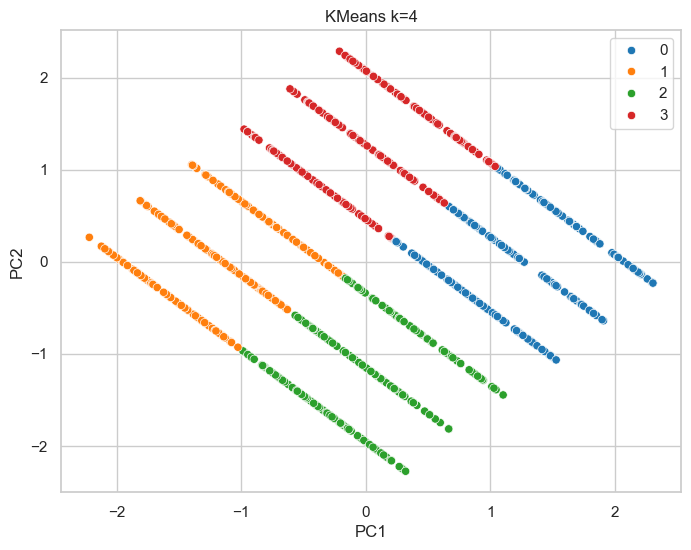

Cluster counts:
 1    264
2    255
0    248
3    233
Name: count, dtype: int64


In [12]:
k_results = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    counts = np.bincount(labels)
    k_results.append({'algo':'KMeans','k':k,'silhouette':sil,'db':db,'counts':counts})

kdf = pd.DataFrame(k_results).sort_values('silhouette', ascending=False)
display(kdf[['k','silhouette','db']])
best_k = int(kdf.iloc[0]['k'])
print("Best K (by silhouette):", best_k)

# fit best and plot
best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_scaled)
labels = best_km.labels_
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=labels, palette='tab10', legend='full')
plt.title(f'KMeans k={best_k}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

print("Cluster counts:\n", pd.Series(labels).value_counts())

,linkage,k,silhouette,db
13,average,5,0.404313,0.888427
12,average,4,0.396805,0.789148
14,average,6,0.394462,0.839184
11,average,3,0.373090,0.903257
8,complete,5,0.361017,0.925410
7,complete,4,0.360719,0.768617
4,ward,6,0.354945,0.874984
10,average,2,0.353080,1.168435
9,complete,6,0.352840,0.960144
0,ward,2,0.345901,1.175437


Best Agglo: {'algo': 'Agglo', 'linkage': 'average', 'k': 5, 'silhouette': 0.4043127601419495, 'db': 0.8884272002374823}


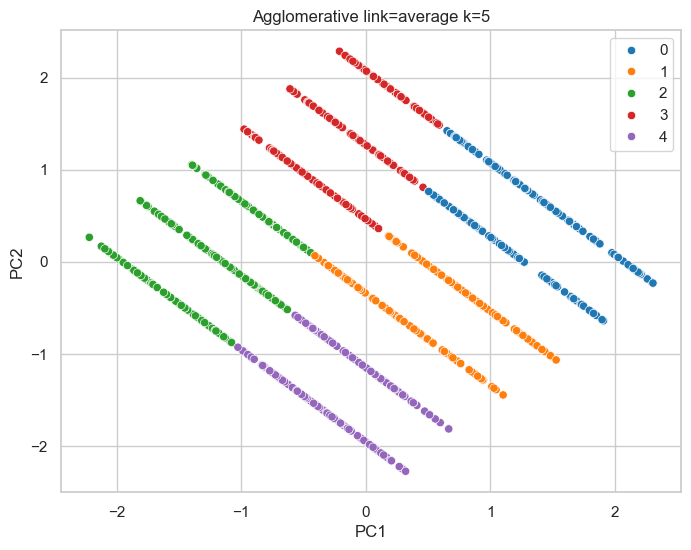

Cluster counts:
 2    245
0    204
1    186
3    185
4    180
Name: count, dtype: int64


In [13]:
agg_results = []
linkages = ['ward','complete','average']  # ward requires euclidean
for link in linkages:
    for k in range(2,7):
        try:
            agg = AgglomerativeClustering(n_clusters=k, linkage=link)
            labels = agg.fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
            agg_results.append({'algo':'Agglo','linkage':link,'k':k,'silhouette':sil,'db':db})
        except Exception as e:
            agg_results.append({'algo':'Agglo','linkage':link,'k':k,'silhouette':np.nan,'db':np.nan})

adf = pd.DataFrame(agg_results).sort_values('silhouette', ascending=False)
display(adf[['linkage','k','silhouette','db']].head(10))
best_row = adf.iloc[0]
print("Best Agglo:", best_row.to_dict())

# plot best
best_agg = AgglomerativeClustering(n_clusters=int(best_row['k']), linkage=best_row['linkage']).fit(X_scaled)
labels = best_agg.labels_
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=labels, palette='tab10', legend='full')
plt.title(f'Agglomerative link={best_row["linkage"]} k={int(best_row["k"])}')
plt.show()

print("Cluster counts:\n", pd.Series(labels).value_counts())

,algo,eps,min_samples,n_clusters,silhouette,db
3,DBSCAN,0.416667,3,6,0.136505,2.922365
4,DBSCAN,0.416667,5,6,0.136505,2.922365
5,DBSCAN,0.416667,7,6,0.136505,2.922365
0,DBSCAN,0.200000,3,7,0.065269,2.389114
1,DBSCAN,0.200000,5,7,0.065269,2.389114
2,DBSCAN,0.200000,7,7,0.065269,2.389114
6,DBSCAN,0.633333,3,1,NaN,NaN
7,DBSCAN,0.633333,5,1,NaN,NaN
8,DBSCAN,0.633333,7,1,NaN,NaN
9,DBSCAN,0.850000,3,1,NaN,NaN


Best DBSCAN params: {'algo': 'DBSCAN', 'eps': 0.4166666666666667, 'min_samples': 3, 'n_clusters': 6, 'silhouette': 0.13650526743255068, 'db': 2.9223653254381308}


C:\Users\youss\AppData\Local\Temp\ipykernel_14028\3823967891.py:30: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=labels, palette=palette, legend='full')


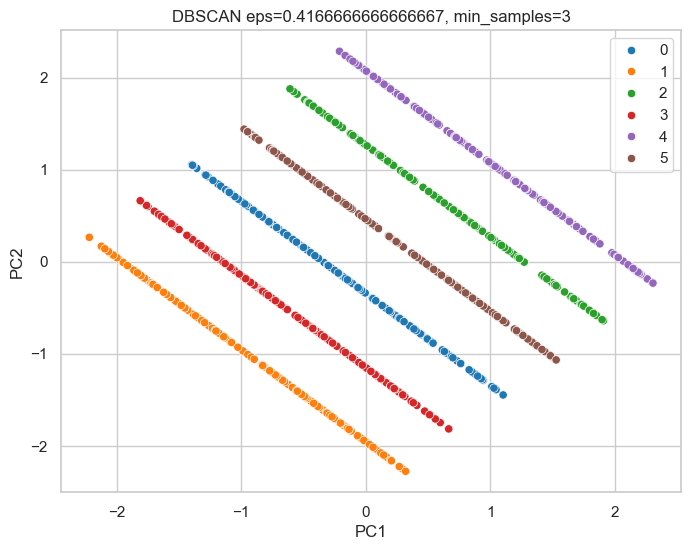

Cluster counts (including noise=-1):
 1    193
4    172
3    169
0    157
5    155
2    154
Name: count, dtype: int64


In [14]:
db_results = []
eps_values = np.linspace(0.2,1.5,7)  # adjust if scale differs
min_samps = [3,5,7]
for eps in eps_values:
    for ms in min_samps:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        unique_labels = set(labels)
        n_clusters = len([l for l in unique_labels if l != -1])
        if n_clusters <= 1:
            sil = np.nan
            dbi = np.nan
        else:
            sil = silhouette_score(X_scaled, labels)
            dbi = davies_bouldin_score(X_scaled, labels)
        db_results.append({'algo':'DBSCAN','eps':eps,'min_samples':ms,'n_clusters':n_clusters,'silhouette':sil,'db':dbi})

dbdf = pd.DataFrame(db_results).sort_values('silhouette', ascending=False)
display(dbdf.head(10))

# pick best valid entry (non-nan silhouette)
best_db = dbdf[dbdf['silhouette'].notna()].iloc[0]
print("Best DBSCAN params:", best_db.to_dict())

# fit and plot best
db_best = DBSCAN(eps=float(best_db['eps']), min_samples=int(best_db['min_samples'])).fit(X_scaled)
labels = db_best.labels_
plt.figure(figsize=(8,6))
palette = sns.color_palette("tab10", n_colors=len(set(labels))+1)
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=labels, palette=palette, legend='full')
plt.title(f"DBSCAN eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}")
plt.show()

print("Cluster counts (including noise=-1):\n", pd.Series(labels).value_counts())

In [15]:
# collate best metrics from previous dataframes
best_k_row = kdf.iloc[0]
best_agg_row = adf.iloc[0]
# select only rows with a valid silhouette
valid_db = dbdf[dbdf['silhouette'].notna()]

# choose best if any valid rows exist, otherwise None
best_db_row = valid_db.iloc[0] if not valid_db.empty else None

summary = []
summary.append({'algo':'KMeans','params':f"k={int(best_k_row['k'])}",'silhouette':best_k_row['silhouette'],'db':best_k_row['db']})
summary.append({'algo':'Agglomerative','params':f"link={best_agg_row['linkage']} k={int(best_agg_row['k'])}",'silhouette':best_agg_row['silhouette'],'db':best_agg_row['db']})
if best_db_row is not None:
    print("Best DBSCAN params:", best_db_row.to_dict())
    db_best = DBSCAN(eps=float(best_db_row['eps']), min_samples=int(best_db_row['min_samples'])).fit(X_scaled)
    labels = db_best.labels_
    # plotting code...
else:
    print("No valid DBSCAN clustering found (all trials produced <=1 cluster). Try widening eps/min_samples grid.")

summary_df = pd.DataFrame(summary).sort_values('silhouette', ascending=False)
display(summary_df)

# Example: inspect plant distribution in best KMeans (change to your preferred result)
chosen_labels = best_km.labels_
joined = df.loc[X_index].copy()
joined['cluster'] = chosen_labels
display(pd.crosstab(joined['Plant_ID'], joined['cluster']))

Best DBSCAN params: {'algo': 'DBSCAN', 'eps': 0.4166666666666667, 'min_samples': 3, 'n_clusters': 6, 'silhouette': 0.13650526743255068, 'db': 2.9223653254381308}


,algo,params,silhouette,db
0,KMeans,k=4,0.429401,0.748424
1,Agglomerative,link=average k=5,0.404313,0.888427


cluster,0,1,2,3
Plant_ID,,,,
Aglaonema commutatum,12,15,7,18
Aloe vera,10,12,17,16
Anthurium andraeanum,17,10,8,15
Begonia maculata,15,14,11,11
Calathea orbifolia,8,15,14,10
Chlorophytum comosum,13,10,10,18
Codiaeum variegatum,10,12,15,8
Dieffenbachia seguine,9,12,12,8
Dracaena trifasciata,16,16,15,12


In [16]:
summary_df

,algo,params,silhouette,db
0,KMeans,k=4,0.429401,0.748424
1,Agglomerative,link=average k=5,0.404313,0.888427


In [ ]:
# Plot the watering amount and the watering frequesncy, without PCA

watering_frequency_scaled = scaler.fit_transform(df[['Watering_Frequency_days']]).ravel()
watering_amount_scaled = scaler.fit_transform(df[['Watering_Amount_ml']]).ravel()

plt.figure(figsize=(8,6))
sns.scatterplot(x=watering_frequency_scaled, y=watering_amount_scaled, hue=df['Plant_ID'], palette='tab20', legend='full')
plt.title('Watering Frequency vs Amount by Plant ID')
plt.xlabel('Watering Frequency (days)')
plt.ylabel('Watering Amount (ml)')
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

<Figure size 800x600 with 0 Axes>